In [1]:
from eht_inspection.fringe import *

check_hops_env()


HOPS/EAT mk4 is available.


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt


Notice:

1. If using only a single fringe file, spectrum() cannot be used as it will automatically find the associated corel file (type 120 data), the output from correlator in the same directory.

2. Control file can be used inside spectrum() with precorrect=True, the purpose of doing so is ...

3. For our inspection, type 212 data, the complex visibilities with shape (nap, nchan), are sufficient

Documentation:

1. findfringe() can be used to find best-fit delay rate and delay

2. adhoc() estimates an ad-hoc baseline phase correction from type-212 data and returns corrected visibility-like arrays, shape (nap, nchan), this assumes a-priori phase bandpass and fringe rotation (delay) has been applied. One can compare the before and after-correction bandpass by calling adhoc(). However, this is not the first choice for our inspection as spectrum() automitcally applies it.

3. timeseries() if kind=120, it averages over channel + spectral point, then optionally averages over AP using dt; if kind=212, it averages over channel, then optionallys average over AP using dt

4. spectrum() averages over AP/time, keeps channel/spectral structure, and optionally rebins frequency with df

In [3]:
# fringe files and control files are all from EHTHOPS stage 3.+adhoc for 2022 M87 data

fname = "data/AX.B.17.43RHPD"
cf_path = "data/cf_all"

In [4]:
ff = get_fringe_file(fname)


data/AX.B.17.43RHPD


In [5]:
p = get_fringe_params(ff)
print(p.baseline, p.pol, p.source, p.snr)
print(p.sbd, p.mbd, p.delay, p.rate)
print(p.nchan, p.nap, p.ref_freq)


AX XL M87 1187.85986328125
-0.002067034598439932 -0.002163722412660718 -0.002163722412660718 1.5615971449278732e-07
32 750 227070.703125


In [6]:
get_polarization(fname)


'XL'

In [7]:
# load certain types of data
# type-120 data are only available when the corresponding correlator file is present
v212 = load_type212(ff)
# v120 = load_type120(ff)


rotation subtracted from data: 2.164 [ns], -0.156 [ps/s]
1199593.4285021727


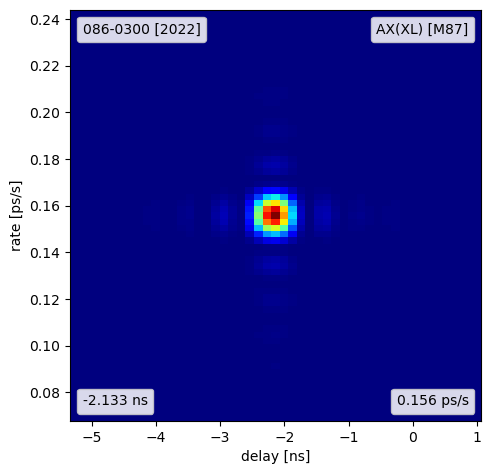

In [8]:
find_fringe(ff, kind=212)


In [9]:
before, after_output = apply_adhoc(ff)


In [10]:
vcorr_chavg = np.nanmean(after_output.vcorr, axis=1)

phase_corr = np.angle(vcorr_chavg)
amp_corr = np.abs(vcorr_chavg)

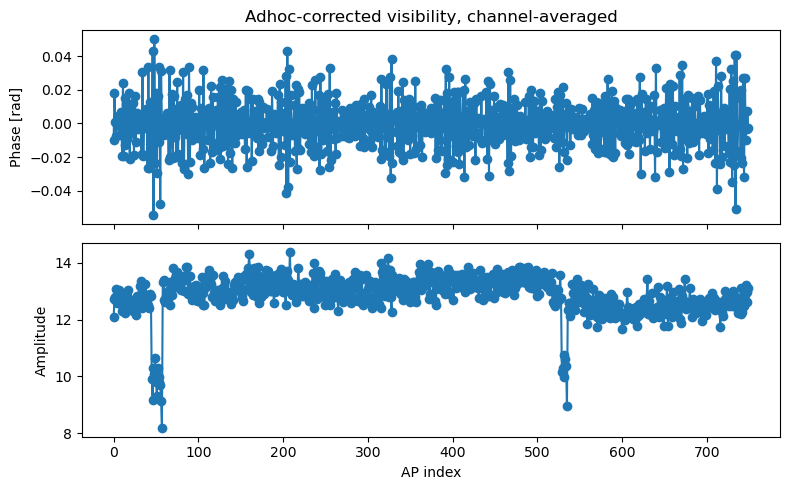

In [11]:
# plot adhoc-phase-corrected data
ap_idx = np.arange(len(vcorr_chavg))

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 5))
axs[0].plot(ap_idx, phase_corr, "o-")
axs[0].set_ylabel("Phase [rad]")
axs[0].set_title("Adhoc-corrected visibility, channel-averaged")
axs[1].plot(ap_idx, amp_corr, "o-")
axs[1].set_xlabel("AP index")
axs[1].set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

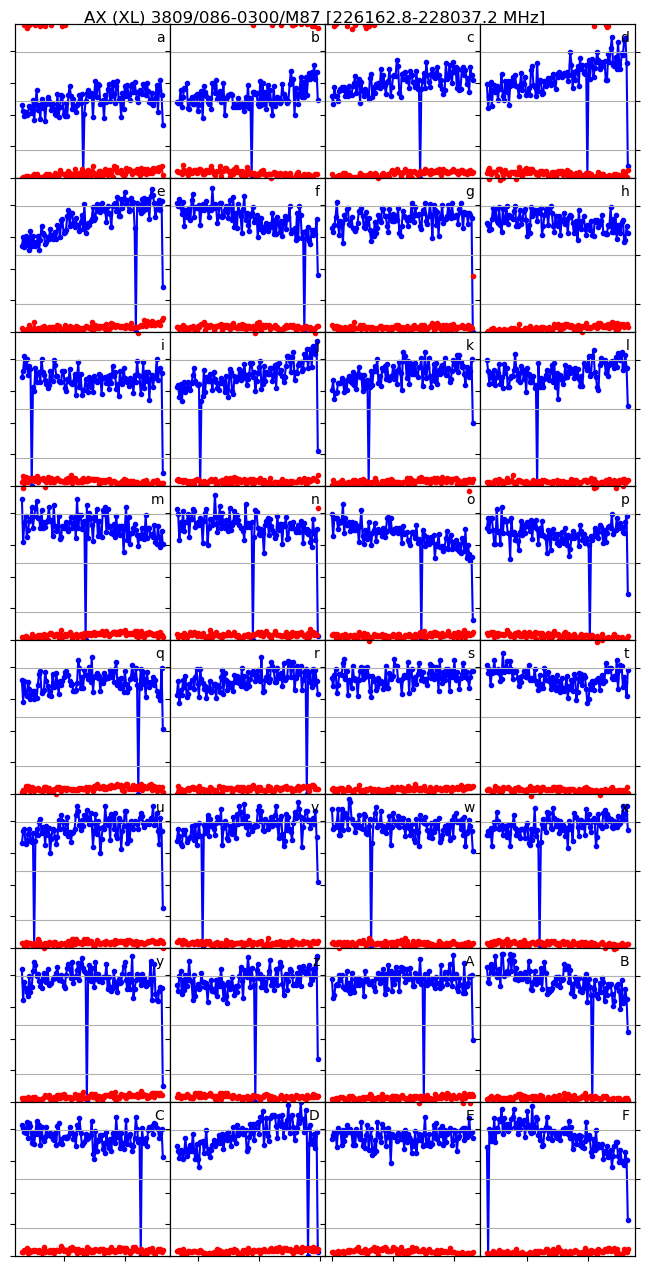

In [12]:
spectrum(ff, cf=cf_path, precorrect=True)


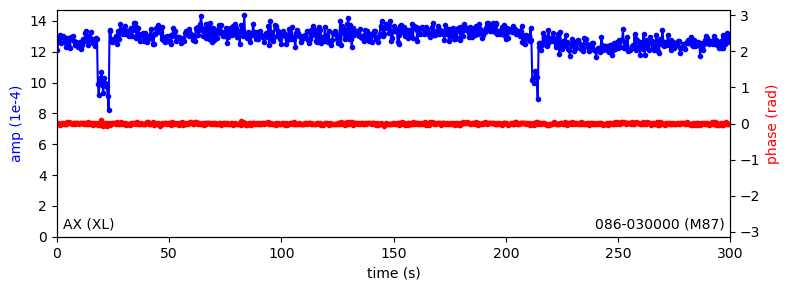

In [13]:
timeseries(ff)


In [14]:
pdf_path = export_fplot_pdf(fname, outdir="pdf")
print(pdf_path)


pdf/AX.B.17.43RHPD_fplot.pdf


In [15]:
fplot(fname)
